Triplet Loss deneme

Kodlama işlemi Google Colab üzerinden gerçekleştirilmiştir. Jupyter Notebook üzerinde kütüphanelerin kullanımında sorunların çıkma olasılığı, veri tabanlarına kolay bir şekilde ulaşım ve drive dosyalarının kolaylıkla kullanılabilmesi amacıyla bu kodlama ortamı kullanılmıştır. Aşağıdaki linkten Google Colab ortamına erişebilirsiniz. Çalışmanızda kolaylıklar dilerim. Defne BENLİAY

https://colab.research.google.com/drive/1rvNqiYHYnFzI86ifLn70FNVqr7G_wQU-?usp=sharing

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
import os
from sklearn.preprocessing import LabelEncoder
import zipfile
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from google.colab import files
from google.colab import drive
from tensorflow.keras import backend as K

In [ ]:

drive.mount('/content/drive')
zip_path = '/content/drive/MyDrive/archive.zip'
unzip_dir = '/content/archive/'
os.makedirs(unzip_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(unzip_dir)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
for root, dirs, files in os.walk('/content/archive/'):
    for name in files:
        print(os.path.join(root, name))
    for name in dirs:
        print(os.path.join(root, name))

/content/archive/data
/content/archive/val
/content/archive/train
/content/archive/data/val
/content/archive/data/train
/content/archive/data/val/jerry_seinfeld
/content/archive/data/val/elton_john
/content/archive/data/val/ben_afflek
/content/archive/data/val/mindy_kaling
/content/archive/data/val/madonna
/content/archive/data/val/jerry_seinfeld/httpcdnssninsidercomwpcontentuploadsjerryseinfeldxjpg.jpg
/content/archive/data/val/jerry_seinfeld/httpaurorasblogcomwpcontentuploadsjerryseinfeldpublicityshotjpg.jpg
/content/archive/data/val/jerry_seinfeld/httpblognjcomentertainmentimpactcelebritiesmediumjerrybjpg.jpg
/content/archive/data/val/jerry_seinfeld/httpafilesbiographycomimageuploadcfillcssrgbdprgfacehqwMTIwNjANjMMDINzIxNjcjpg.jpg
/content/archive/data/val/jerry_seinfeld/httpcdncdnjustjaredcomwpcontentuploadsheadlinesjerryseinfeldmakesbrianwilliamsjokejpg.jpg
/content/archive/data/val/elton_john/httpcdncdnjustjaredcomwpcontentuploadsheadlineseltonjohnemmysperformancewatchnowjpg.jpg


In [ ]:
!wget https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml -O haar.xml

--2026-04-25 17:31:35--  https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 930127 (908K) [text/plain]
Saving to: ‘haar.xml’

haar.xml            100%[===================>] 908.33K  --.-KB/s    in 0.03s   

2026-04-25 17:31:35 (31.3 MB/s) - ‘haar.xml’ saved [930127/930127]



[[ 50  50 108 108]]


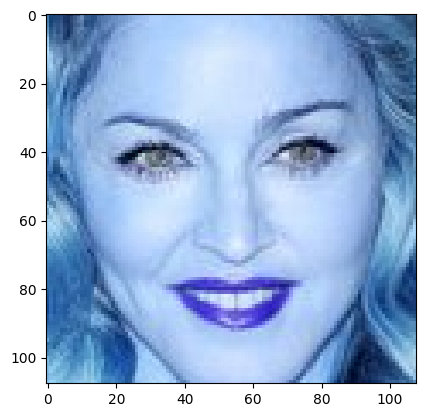

In [ ]:
haar_cascade_path = '/content/haar.xml'
face_cascade = cv2.CascadeClassifier(haar_cascade_path)
image_path = "/content/archive/data/train/madonna/httpiamediaimdbcomimagesMMVBMTANDQNTAxNDVeQTJeQWpwZBbWUMDIMjQOTYVUXCRALjpg.jpg"
f = cv2.imread(image_path)

faces = face_cascade.detectMultiScale(f,1.3,5)
print(faces)
for x,y,w,h in faces:
    plt.imshow(f[y:y+h, x:x+w])


In [ ]:
dirs = "/content/archive/data/train/"
img_size = 60
data = []
for name in os.listdir(dirs):
    for f in os.listdir(dirs+name):
        f = cv2.imread(os.path.join(dirs+name, f))
        faces = face_cascade.detectMultiScale(f,1.3,5)
        for x,y,w,h in faces:
            img = f[y:y+h, x:x+w]
            img = cv2.resize(img, (img_size,img_size))
            data.append((img, name))

df = pd.DataFrame(data, columns=["image", "name"])
print("Length:",len(df))

Length: 75


In [ ]:
df.head()

,image,name
0,"[[[250, 249, 251], [254, 253, 254], [252, 252,...",jerry_seinfeld
1,"[[[38, 49, 80], [66, 83, 124], [90, 113, 162],...",jerry_seinfeld
2,"[[[250, 250, 250], [250, 250, 250], [250, 250,...",jerry_seinfeld
3,"[[[237, 232, 223], [237, 232, 223], [236, 231,...",jerry_seinfeld
4,"[[[51, 65, 54], [37, 52, 44], [44, 61, 57], [9...",jerry_seinfeld


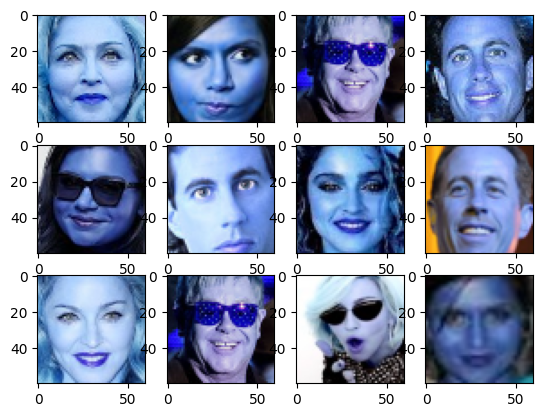

In [ ]:
for i in range(12):
  row = df.iloc[np.random.randint(0, len(df)), :]
  plt.subplot(3,4,i+1)
  plt.imshow(row['image'])


In [ ]:
dirs = "/content/archive/data/val/"

data = []
for name in os.listdir(dirs):
    for f in os.listdir(dirs+name):
        f = cv2.imread(os.path.join(dirs+name, f))
        faces = face_cascade.detectMultiScale(f,1.3,5)
        for x,y,w,h in faces:
            img = f[y:y+h, x:x+w]
            img = cv2.resize(img, (img_size,img_size))
            data.append((img, name))

df_test = pd.DataFrame(data, columns=["image", "name"])
print("Test size: ", len(df_test))

Test size:  24


In [ ]:
df_test.head()



,image,name
0,"[[[56, 48, 49], [53, 48, 50], [52, 51, 53], [5...",jerry_seinfeld
1,"[[[33, 30, 23], [30, 27, 22], [26, 24, 20], [2...",jerry_seinfeld
2,"[[[102, 131, 171], [83, 112, 148], [51, 54, 54...",jerry_seinfeld
3,"[[[5, 14, 4], [5, 14, 4], [5, 17, 5], [5, 21, ...",jerry_seinfeld
4,"[[[24, 36, 78], [23, 35, 78], [23, 36, 76], [1...",jerry_seinfeld


In [ ]:
le = LabelEncoder()
le.fit(df["name"].values)

LabelEncoder()

In [ ]:
x_train = list(df['image'].values)
x_train = np.array(x_train)
x_train = x_train/255
print(x_train.shape)

y_train = le.transform(df["name"].values)
print(y_train.shape)

(75, 60, 60, 3)
(75,)


In [ ]:
x_test = list(df_test['image'].values)
x_test = np.array(x_test)
x_test = x_test/255
print(x_test.shape)

y_test = le.transform(df_test["name"].values)
print(y_test.shape)

(24, 60, 60, 3)
(24,)


In [ ]:
people_num = len(np.unique(y_train))
people_num

5

In [ ]:
def triplet_loss(y_true, y_pred, alpha = 0.2):
    total_lenght = y_pred.shape.as_list()[-1]
    anchor, positive, negative = y_pred[:,:int(1/3*total_lenght)], y_pred[:,int(1/3*total_lenght):int(2/3*total_lenght)], y_pred[:,int(2/3*total_lenght):]

    pos_dist = tf.reduce_sum(tf.square(anchor - positive), axis=-1)
    neg_dist = tf.reduce_sum(tf.square(anchor - negative), axis=-1)
    basic_loss = pos_dist - neg_dist + alpha
    loss = tf.reduce_sum(tf.maximum(basic_loss,0.0))
    return loss

In [ ]:
def generate_triplets(x, y, num_same, num_diff):
    anchor_images = np.array([]).reshape((-1,)+ x.shape[1:])
    same_images = np.array([]).reshape((-1,)+ x.shape[1:])
    diff_images = np.array([]).reshape((-1,)+ x.shape[1:])

    for i in range(len(y)):
        point = y[i]
        anchor = x[i]

        same_pairs = np.where(y == point)[0]
        same_pairs = np.delete(same_pairs , np.where(same_pairs == i))
        diff_pairs = np.where(y != point)[0]

        same = x[np.random.choice(same_pairs,num_same)]
        diff = x[np.random.choice(diff_pairs,num_diff)]

        anchor_images = np.concatenate((anchor_images, np.tile(anchor, (num_same * num_diff, 1, 1, 1) )), axis = 0)

        for s in same:
            same_images = np.concatenate((same_images, np.tile(s, (num_same, 1, 1, 1) )), axis = 0)
        diff_images = np.concatenate((diff_images, np.tile(diff, (num_diff, 1, 1, 1) )), axis = 0)

    return anchor_images, same_images, diff_images

In [ ]:
anchor_images, same_images, diff_images = generate_triplets(x_train,y_train, num_same= 10, num_diff=10)
print(anchor_images.shape, same_images.shape, diff_images.shape)

(7500, 60, 60, 3) (7500, 60, 60, 3) (7500, 60, 60, 3)


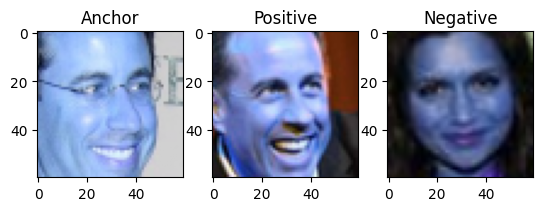

In [ ]:
idx = 100
plt.subplot(1,3,1)
plt.imshow(anchor_images[idx])
plt.title('Anchor')

plt.subplot(1,3,2)
plt.imshow(same_images[idx])
plt.title('Positive')

plt.subplot(1,3,3)
plt.imshow(diff_images[idx])
plt.title('Negative')
print()

Building and Fitting the CNN Model

In [ ]:
def get_model():
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Conv2D(64, kernel_size=3, strides=2, padding='same', input_shape=(img_size,img_size,3), activation='relu'))
    model.add(tf.keras.layers.Conv2D(128, kernel_size=3, strides=2, padding='same', activation='relu'))
    model.add(tf.keras.layers.Conv2D(64, kernel_size=3, strides=2, padding='same', activation='relu'))
    model.add(tf.keras.layers.Conv2D(64, kernel_size=1, strides=2, padding='same', activation='relu'))
    model.add(tf.keras.layers.Flatten())

    model.add(tf.keras.layers.Dense(256, activation='relu'))
    model.add(tf.keras.layers.Dropout(0.1))
    model.add(tf.keras.layers.Dense(128))
    model.add(tf.keras.layers.Lambda(lambda x: K.l2_normalize(x, axis=1)))

    # model.summary() # Modeli ilk kez çağırdıktan sonra summary'yi çağırabilirsiniz
    return model

In [ ]:
anchor_input = tf.keras.layers.Input((img_size, img_size, 3), name='anchor_input')
positive_input = tf.keras.layers.Input((img_size, img_size, 3), name='positive_input')
negative_input = tf.keras.layers.Input((img_size, img_size, 3), name='negative_input')

shared_dnn = get_model()
encoded_anchor = shared_dnn(anchor_input)
encoded_positive = shared_dnn(positive_input)
encoded_negative = shared_dnn(negative_input)
merged_vector = tf.keras.layers.concatenate([encoded_anchor, encoded_positive, encoded_negative], axis=-1, name='merged_layer')

model = tf.keras.Model(inputs=[anchor_input,positive_input, negative_input], outputs=merged_vector)
model.summary()
model.compile(loss=triplet_loss, optimizer="adam")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "functional_68"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ anchor_input        │ (None, 60, 60, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positive_input      │ (None, 60, 60, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ negative_input      │ (None, 60, 60, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_6        │ (None, 128)       │    448,896 │ anchor_input[0][… │
│ (Sequential)        │                   │            │ positive_input[0… │
│                     │                   │            │ negative_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ merged_layer        │ (None, 384)       │          0 │ sequential_6[0][… │
│ (Concatenate)       │                   │            │ sequential_6[1][… │
│                     │                   │            │ sequential_6[2][… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 448,896 (1.71 MB)

 Trainable params: 448,896 (1.71 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
Y_dummy = np.empty((anchor_images.shape[0],1))
model.fit([anchor_images,same_images,diff_images],y=Y_dummy, batch_size=128, epochs=10)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/array_slicing.py:63: RuntimeWarning: overflow encountered in cast
  return x.astype(dtype)


Epoch 1/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 11s 97ms/step - loss: 9.9949
Epoch 2/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.1890
Epoch 3/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0949
Epoch 4/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0298
Epoch 5/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0164
Epoch 6/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0975
Epoch 7/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0538
Epoch 8/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0177
Epoch 9/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0128
Epoch 10/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 6.8388e-04


In [ ]:
anchor_model = tf.keras.Model(inputs = anchor_input, outputs=encoded_anchor)

In [ ]:
pred = anchor_model.predict(x_train)
pred.shape

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 197ms/step


(75, 128)

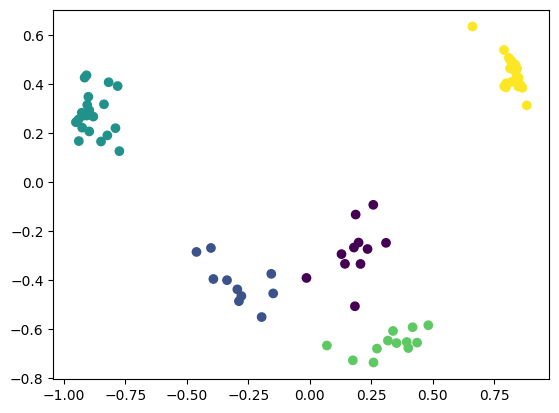

In [ ]:
pca = PCA(n_components=2)
pred_pca = pca.fit_transform(pred)
plt.scatter(pred_pca[:,0], pred_pca[:,1], c=y_train)

Face Recognition using KNN

In [ ]:
def encode_image(model ,img):
    encode = model.predict(img.reshape((1,)+ img.shape))
    return encode

In [ ]:
pred_x_train = anchor_model.predict(x_train)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


In [ ]:
neigh = KNeighborsClassifier(n_neighbors=7)
neigh.fit(pred_x_train, y_train)

KNeighborsClassifier(n_neighbors=7)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step
Predicted name: ['madonna']
Actual pred:  ['elton_john']


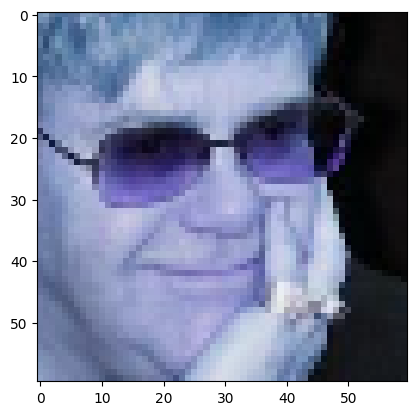

In [ ]:
idx = 8
img = x_test[idx]
plt.imshow(img)

enc = encode_image(anchor_model, img)
pred = neigh.predict(enc)
print("Predicted name:",le.inverse_transform(pred))
print("Actual pred: ", le.inverse_transform(y_test[idx:idx+1]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Predicted name: ['ben_afflek']
Actual pred:  ['ben_afflek']


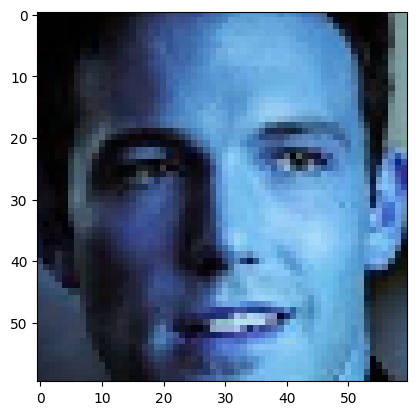

In [ ]:
idx = 10
img = x_test[idx]
plt.imshow(img)

enc = encode_image(anchor_model, img)
pred = neigh.predict(enc)
print("Predicted name:",le.inverse_transform(pred))
print("Actual pred: ", le.inverse_transform(y_test[idx:idx+1]))

Saving sei.jpg to sei (3).jpg
User uploaded file "sei (3).jpg"
Found 1 face(s) in the uploaded image.


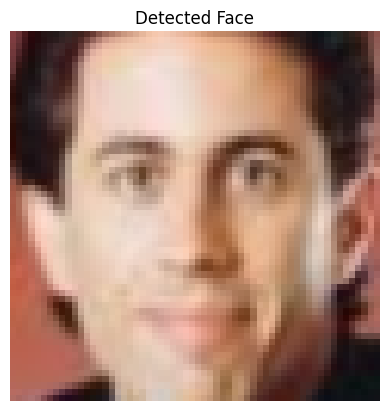

Normalized face shape: (60, 60, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Predicted name: ['jerry_seinfeld']


In [ ]:
from google.colab import files
uploaded = files.upload()

for fn in uploaded.keys():
  uploaded_image_path = fn
  print(f'User uploaded file "{uploaded_image_path}"')
  break

img = cv2.imread(uploaded_image_path)


# Check if the image was loaded successfully
if img_uploaded is None:
    print(f"Error: Could not load image from {uploaded_image_path}")
else:
    faces_uploaded = face_cascade.detectMultiScale(img, 1.3, 5)

    if len(faces_uploaded) == 0:
        print("No faces detected in the uploaded image.")
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)) # Convert to RGB for display
        plt.title('No Face Detected')
        plt.axis('off')
        plt.show()
    else:
        print(f"Found {len(faces_uploaded)} face(s) in the uploaded image.")
        x, y, w, h = faces_uploaded[0]

        face_crop = img[y:y+h, x:x+w]
        face_resized = cv2.resize(face_crop, (img_size, img_size))

        face_normalized = face_resized / 255.0

        plt.imshow(cv2.cvtColor(face_normalized.astype(np.float32), cv2.COLOR_BGR2RGB)) # Convert to RGB for display
        plt.title('Detected Face')
        plt.axis('off')
        plt.show()

        print(f"Normalized face shape: {face_normalized.shape}")

        enc = encode_image(anchor_model, face_normalized)
        pred = neigh.predict(enc)
        print("Predicted name:",le.inverse_transform(pred))


In [ ]:
pred_x_test = anchor_model.predict(x_test)
pred = neigh.predict(pred_x_test)

print("Accuracy ->",np.sum(pred == y_test)/len(pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 837ms/step
Accuracy -> 0.6666666666666666
